## Script to sync EMFIT to PSG.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, resample
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
import mne
from pathlib import Path

# === CONFIGURATION — change these as needed ===
PARTICIPANT = "MS35"
VISIT = "Visit_1"
NIGHT = "Night_1"
PSG_FS = 32          # PSG actigraphy sampling rate (Hz)
EMFIT_FS = 100       # EMFIT sampling rate (Hz)
SMOOTH_WINDOW_S = 10 # Smoothing window in seconds
PREVIEW_WINDOW_S = 30 * 60  # Preview window in seconds (30 minutes)
CORR_ZOOM_S = 600    # Cross-correlation plot zoom in seconds

# === PATHS ===
processed_dir = Path(f"C:/Users/ryadl/Desktop/EMFIT_Local/Emfit_1/data/processed/{PARTICIPANT}/{VISIT}")
intermediate_dir = Path(f"C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/data/intermediate/{PARTICIPANT}/{VISIT}")

### Load PSG akti files.

In [8]:
# Try default filename first, then V1/V2 variants
akti_path = processed_dir / f"{PARTICIPANT}_PSG_akti.txt"

if not akti_path.exists():
    v1_path = processed_dir / f"{PARTICIPANT}V1_PSG_akti.txt"
    v2_path = processed_dir / f"{PARTICIPANT}V2_PSG_akti.txt"
    
    if VISIT == "Visit_1" and v1_path.exists():
        akti_path = v1_path
        print(f"Using V1 akti file: {akti_path.name}")
    elif VISIT == "Visit_2" and v2_path.exists():
        akti_path = v2_path
        print(f"Using V2 akti file: {akti_path.name}")
    else:
        print(f"No PSG akti file found for {PARTICIPANT} {VISIT}, skipping...")
        raise FileNotFoundError(f"No akti file found for {PARTICIPANT}")

akti = pd.read_csv(akti_path, sep='\t')
print(f"PSG akti loaded: {akti.shape[0]} rows at {PSG_FS}Hz")
print(f"PSG start: {akti['HMS'].iloc[0]}")
print(f"PSG end: {akti['HMS'].iloc[-1]}")

PSG akti loaded: 1001280 rows at 32Hz
PSG start: 22:37:30
PSG end: 07:18:59.96875


### Loading EMFIT .edf file.

In [9]:
mne.set_log_level('WARNING')
edf_path = list((intermediate_dir / NIGHT / "edf").glob("*.edf"))[0]
print(f"Loading EDF: {edf_path.name}")

raw = mne.io.read_raw_edf(edf_path, preload=True)

# Use BCG-Raw-Low preferentially — better for postural shifts
# Use BCG-Raw-High if Low is unavailable
if 'BCG-Raw-Low' in raw.ch_names:
    bcg_channel = 'BCG-Raw-Low'
else:
    bcg_channel = 'BCG-Raw-High'
    print("Warning: BCG-Raw-Low not found, using BCG-Raw-High instead")

emfit_signal = raw.get_data(picks=bcg_channel)[0]
emfit_fs_actual = raw.info['sfreq']

print(f"Using channel: {bcg_channel}")
print(f"EMFIT signal loaded: {len(emfit_signal)} samples at {emfit_fs_actual}Hz")
print(f"EMFIT duration: {len(emfit_signal)/emfit_fs_actual/3600:.2f} hours")

Loading EDF: MS35_Emfit2_20240724_2228_20240725_1211_UTC+1.edf
Using channel: BCG-Raw-Low
EMFIT signal loaded: 4942200 samples at 100.0Hz
EMFIT duration: 13.73 hours


### Handles midnight crossing from datetime objects.

In [10]:
def fix_rollover(psg):
    ###
    # Handles midnight crossings in HMS timestamps.
    # When the clock resets from 23:59:59 to 00:00:00,
    # adds 24 hours to all subsequent timestamps.
    ###
    hms = pd.to_timedelta(psg['HMS'].str.strip())
    rollover = 0
    corrected = []
    for i in range(len(hms)):
        if i > 0 and hms.iloc[i] < hms.iloc[i-1]:
            rollover += 1
        corrected.append(hms.iloc[i] + pd.to_timedelta(rollover, unit='day'))
    return pd.to_timedelta(corrected)

akti['time_delta'] = fix_rollover(akti)
psg_duration = akti['time_delta'].iloc[-1] - akti['time_delta'].iloc[0]
print(f"PSG duration after rollover correction: {psg_duration}")

PSG duration after rollover correction: 0 days 08:41:29.968750


### Downsamples EMFIT (100Hz) to PSG (32Hz).

In [11]:
downsample_factor = EMFIT_FS / PSG_FS
n_samples_psg_rate = int(len(emfit_signal) / downsample_factor)
emfit_downsampled = resample(emfit_signal, n_samples_psg_rate)

print(f"EMFIT downsampled: {len(emfit_downsampled)} samples at {PSG_FS}Hz")
print(f"PSG akti:          {len(akti)} samples at {PSG_FS}Hz")

EMFIT downsampled: 1581504 samples at 32Hz
PSG akti:          1001280 samples at 32Hz


### Applies Z-score normalisation to the akti and .edf signals.

In [12]:
# Raw signals (use these if you want to plot unscaled data)
psg_signal = akti['Akti.ext.'].values       # raw PSG
# emfit_downsampled already defined above   # raw EMFIT at 32Hz

# Z-scored signals (dimensionless, comparable across devices)
psg_norm = (psg_signal - np.nanmean(psg_signal)) / (np.nanstd(psg_signal) + 1e-12)
emfit_norm = (emfit_downsampled - np.nanmean(emfit_downsampled)) / (np.nanstd(emfit_downsampled) + 1e-12)

print("Z-score normalisation complete")

Z-score normalisation complete


### Applies Hilbert envelope and smoothing
Hilbert transforming allows us to better visualise the large movements of the tossnturns.

In [13]:
smooth_window_samples = SMOOTH_WINDOW_S * PSG_FS  # e.g. 10s * 32Hz = 320 samples

psg_envelope = np.abs(hilbert(psg_norm))
emfit_envelope = np.abs(hilbert(emfit_norm))

psg_smooth = uniform_filter1d(psg_envelope, size=smooth_window_samples)
emfit_smooth = uniform_filter1d(emfit_envelope, size=smooth_window_samples)

print("Hilbert envelopes computed and smoothed")

Hilbert envelopes computed and smoothed


### Preview plot before aligning.

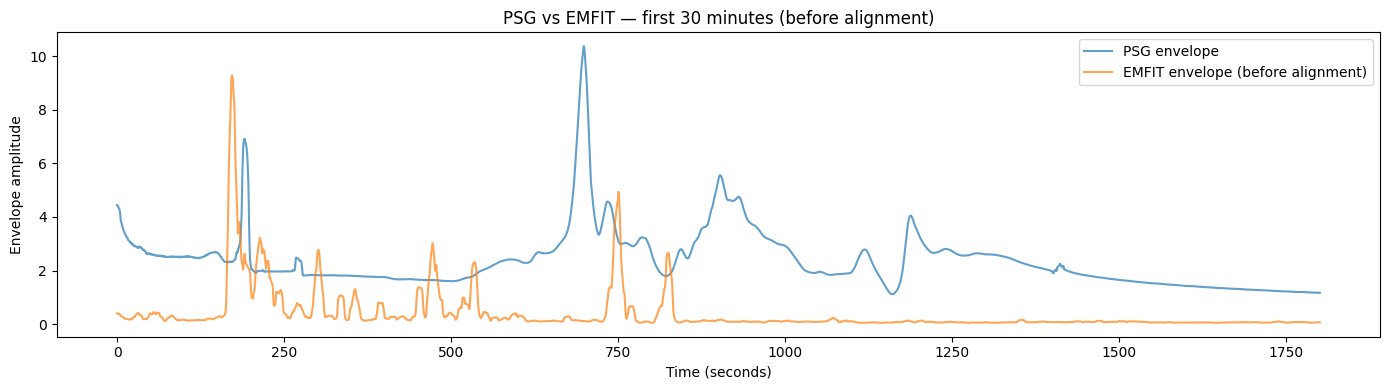

In [14]:
preview_samples = int(PREVIEW_WINDOW_S * PSG_FS)
preview_minutes = PREVIEW_WINDOW_S // 60
time_axis_preview = np.linspace(0, PREVIEW_WINDOW_S, preview_samples)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_axis_preview, psg_smooth[:preview_samples], label='PSG envelope', alpha=0.7)
ax.plot(time_axis_preview, emfit_smooth[:preview_samples], label='EMFIT envelope (before alignment)', alpha=0.7)
ax.set_title(f'PSG vs EMFIT — first {preview_minutes} minutes (before alignment)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Envelope amplitude')
ax.legend()
plt.tight_layout()
plt.show()

### Cross-correlation
Correlates the PSG and EMFIT signals and finds out the lag that best suits the data.

Optimal lag: -555.28 seconds
Interpretation: EMFIT leads PSG by 555.28s


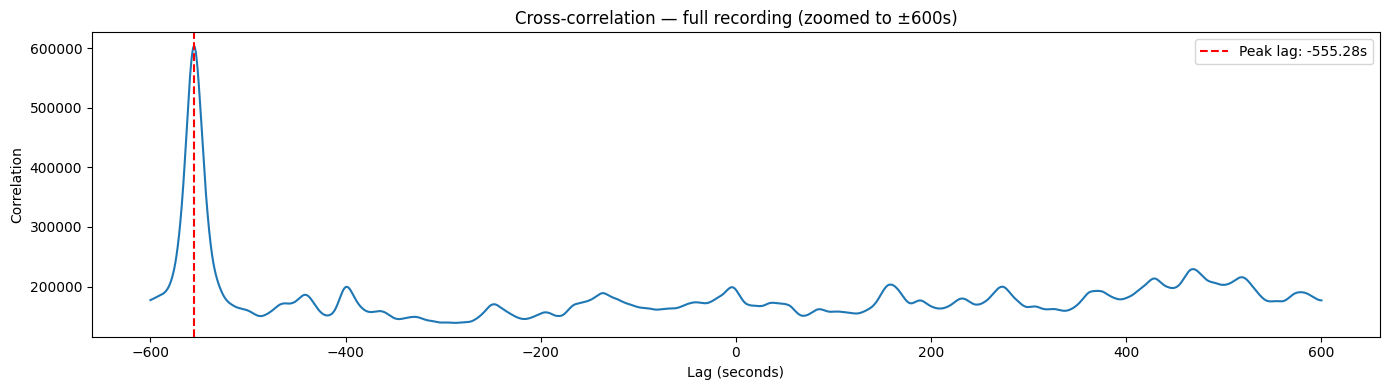

In [15]:
correlation_full = correlate(psg_smooth, emfit_smooth, mode='full')
lags_full = np.arange(-(len(emfit_smooth)-1), len(psg_smooth))

lag_samples = lags_full[np.argmax(correlation_full)]
lag_seconds = lag_samples / PSG_FS

print(f"Optimal lag: {lag_seconds:.2f} seconds")
print(f"Interpretation: {'EMFIT leads PSG' if lag_seconds < 0 else 'PSG leads EMFIT'} by {abs(lag_seconds):.2f}s")

# Plot zoomed to ±CORR_ZOOM_S seconds
mask = (lags_full/PSG_FS >= -CORR_ZOOM_S) & (lags_full/PSG_FS <= CORR_ZOOM_S)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lags_full[mask]/PSG_FS, correlation_full[mask])
ax.axvline(x=lag_seconds, color='r', linestyle='--', label=f'Peak lag: {lag_seconds:.2f}s')
ax.set_title(f'Cross-correlation — full recording (zoomed to ±{CORR_ZOOM_S}s)')
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Correlation')
ax.legend()
plt.tight_layout()
plt.show()

### Apply lag correction to the data.

In [16]:
lag_samples_emfit = int(abs(lag_seconds) * EMFIT_FS)  # convert lag to EMFIT 100Hz samples

if lag_seconds < 0:
    # EMFIT leads PSG — trim start of EMFIT
    emfit_aligned = emfit_signal[lag_samples_emfit:]
    print(f"Trimmed {lag_samples_emfit} samples ({abs(lag_seconds):.2f}s) from start of EMFIT")
else:
    # PSG leads EMFIT — pad start of EMFIT
    emfit_aligned = np.pad(emfit_signal, (lag_samples_emfit, 0))
    print(f"Padded {lag_samples_emfit} samples ({abs(lag_seconds):.2f}s) to start of EMFIT")

# Downsample and normalise aligned signal for plotting
emfit_aligned_ds = resample(emfit_aligned, int(len(emfit_aligned) / downsample_factor))
emfit_aligned_ds_norm = (emfit_aligned_ds - np.nanmean(emfit_aligned_ds)) / (np.nanstd(emfit_aligned_ds) + 1e-12)
emfit_aligned_envelope = uniform_filter1d(np.abs(hilbert(emfit_aligned_ds_norm)), size=smooth_window_samples)

print(f"Aligned EMFIT length: {len(emfit_aligned)} samples at {EMFIT_FS}Hz")

Trimmed 55528 samples (555.28s) from start of EMFIT
Aligned EMFIT length: 4886672 samples at 100Hz


### Interactive alignment check.
Change the start_second and window_seconds to change where in the recording you are looking.

time_axis_psg:       1001280
psg_raw_plot:        1001280
time_axis_emfit_raw: 1563735
emfit_raw_plot:      1563735
time_axis_emfit:     1563735
emfit_aligned_envelope: 1563735


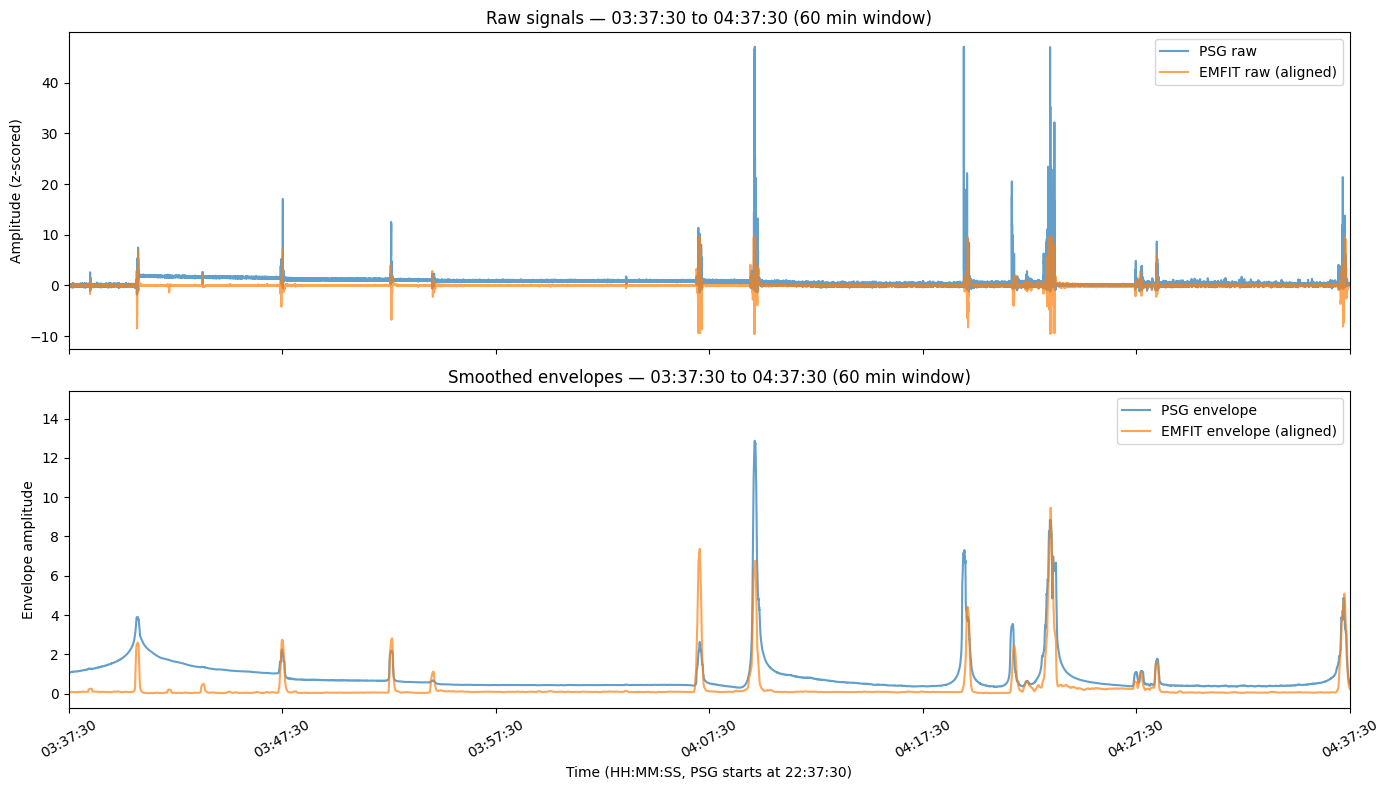

In [18]:
# === CHANGE THESE to explore different parts of the recording ===
start_hms = "05:00:00"   # Relative start time from PSG start in HH:MM:SS
window_minutes = 60    # Window width in minutes

# Convert start_hms to seconds
h, m, s = map(int, start_hms.split(':'))
start_second = h * 3600 + m * 60 + s
window_seconds = window_minutes * 60

# Define raw plot signals first
psg_raw_plot = psg_signal / (np.nanstd(psg_signal) + 1e-12)
emfit_raw_plot = emfit_aligned_ds / (np.nanstd(emfit_aligned_ds) + 1e-12)

# Time axes relative to PSG start (in seconds)
time_axis_psg = np.linspace(0, len(psg_smooth)/PSG_FS, len(psg_smooth))
time_axis_emfit = np.linspace(0, len(emfit_aligned_envelope)/PSG_FS, len(emfit_aligned_envelope))
time_axis_emfit_raw = np.linspace(0, len(emfit_raw_plot)/PSG_FS, len(emfit_raw_plot))

# Checks the differences between them
print(f"time_axis_psg:       {len(time_axis_psg)}")
print(f"psg_raw_plot:        {len(psg_raw_plot)}")
print(f"time_axis_emfit_raw: {len(time_axis_emfit_raw)}")
print(f"emfit_raw_plot:      {len(emfit_raw_plot)}")
print(f"time_axis_emfit:     {len(time_axis_emfit)}")
print(f"emfit_aligned_envelope: {len(emfit_aligned_envelope)}")

# PSG absolute start time for HH:MM:SS labels
psg_start_timedelta = akti['time_delta'].iloc[0]

def seconds_to_hms(seconds_from_psg_start):
    """Convert seconds from PSG start to absolute HH:MM:SS string"""
    absolute = psg_start_timedelta + pd.to_timedelta(seconds_from_psg_start, unit='s')
    total_seconds = int(absolute.total_seconds())
    h = (total_seconds // 3600) % 24
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

# Build x-axis tick labels in HH:MM:SS
n_ticks = 7
tick_positions = np.linspace(start_second, start_second + window_seconds, n_ticks)
tick_labels = [seconds_to_hms(t) for t in tick_positions]

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Raw signals
psg_raw_plot = psg_signal / (np.nanstd(psg_signal) + 1e-12)
emfit_raw_plot = emfit_aligned_ds / (np.nanstd(emfit_aligned_ds) + 1e-12)

axs[0].plot(time_axis_psg, psg_raw_plot, label='PSG raw', alpha=0.7)
axs[0].plot(time_axis_emfit_raw, emfit_raw_plot, label='EMFIT raw (aligned)', alpha=0.7)
axs[0].set_title(f'Raw signals — {seconds_to_hms(start_second)} to {seconds_to_hms(start_second + window_seconds)} ({window_minutes} min window)')
axs[0].set_ylabel('Amplitude (z-scored)')
axs[0].legend()
axs[0].set_xticks(tick_positions)
axs[0].set_xticklabels(tick_labels, rotation=30)

# Smoothed envelopes
axs[1].plot(time_axis_psg, psg_smooth, label='PSG envelope', alpha=0.7)
axs[1].plot(time_axis_emfit, emfit_aligned_envelope, label='EMFIT envelope (aligned)', alpha=0.7)
axs[1].set_title(f'Smoothed envelopes — {seconds_to_hms(start_second)} to {seconds_to_hms(start_second + window_seconds)} ({window_minutes} min window)')
axs[1].set_xlabel(f'Time (HH:MM:SS, PSG starts at {seconds_to_hms(0)})')
axs[1].set_ylabel('Envelope amplitude')
axs[1].legend()
axs[1].set_xticks(tick_positions)
axs[1].set_xticklabels(tick_labels, rotation=30)

axs[0].set_xlim(start_second, start_second + window_seconds)

plt.tight_layout()
plt.show()

### Saves the lag to emfit_num_log.csv

In [19]:
log_path = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/logs/emfit_num_log.csv")

# Load existing log
log_df = pd.read_csv(log_path)

# Add EMFIT-PSG lag column if it doesn't exist
if 'EMFIT_PSG_lag_seconds' not in log_df.columns:
    log_df['EMFIT_PSG_lag_seconds'] = None

# Update the row for this participant
# Match on participant_id — strip visit suffix for matching
participant_match = log_df['participant_id'].str.strip() == PARTICIPANT

if participant_match.any():
    log_df.loc[participant_match, 'EMFIT_PSG_lag_seconds'] = round(lag_seconds, 2)
    log_df.to_csv(log_path, index=False)
    print(f"Lag of {lag_seconds:.2f}s saved to log for {PARTICIPANT}")
else:
    print(f"Warning: {PARTICIPANT} not found in emfit_num_log.csv — log not updated")

Lag of -555.28s saved to log for MS35
